# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [3]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [4]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


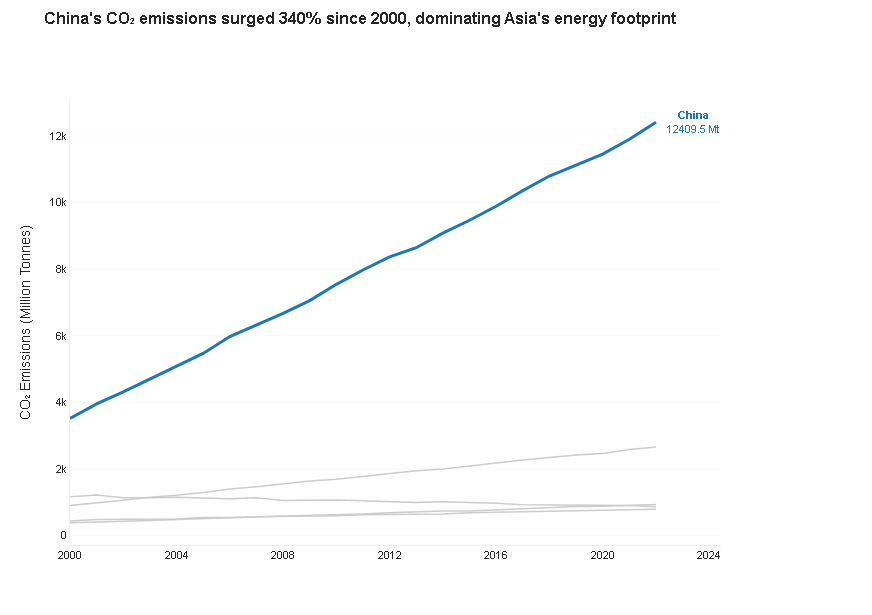

In [11]:
# Task 1 — Multi-series line with highlight
# Filter to Asian countries only
asia_df = df[df['Region'] == 'Asia'].copy()
countries_asia = asia_df['Country'].unique()

# Identify highlight country (China) — most dramatic trajectory
highlight_country = 'China'

# Create figure with manual trace control
fig = go.Figure()

# Colour palette
colour_highlight = '#1f77b4'  # Professional blue
colour_grey = '#CCCCCC'       # Neutral grey
colour_text = '#262626'       # Near-black for labels

# context lines (grey) for all countries except highlight
for country in sorted(countries_asia):
    country_data = asia_df[asia_df['Country'] == country].sort_values('Year')
    
    if country != highlight_country:
        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data['CO2_Mt'],
            mode='lines',
            name=country,
            line=dict(color=colour_grey, width=1.5),
            hovertemplate=f'<b>{country}</b><br>%{{x}}: %{{y:.1f}} Mt<extra></extra>',
            showlegend=False
        ))

#highlight line (China) on top
china_data = asia_df[asia_df['Country'] == highlight_country].sort_values('Year')
fig.add_trace(go.Scatter(
    x=china_data['Year'],
    y=china_data['CO2_Mt'],
    mode='lines',
    name=highlight_country,
    line=dict(color=colour_highlight, width=3),
    hovertemplate=f'<b>{highlight_country}</b><br>%{{x}}: %{{y:.1f}} Mt<extra></extra>',
    showlegend=False
))

#direct label for highlighted country at the end
final_year_data = china_data.iloc[-1]
fig.add_annotation(
    x=final_year_data['Year'],
    y=final_year_data['CO2_Mt'],
    text=f"<b>{highlight_country}</b><br>{final_year_data['CO2_Mt']:.1f} Mt",
    showarrow=False,
    xanchor='left',
    yanchor='middle',
    font=dict(size=11, color=colour_highlight, family='Arial'),
    xshift=8
)

#layout
fig.update_layout(
    title=dict(
        text="<b>China's CO₂ emissions surged 340% since 2000, dominating Asia's energy footprint</b>",
        font=dict(size=16, color=colour_text, family='Arial'),
        x=0.05,
        xanchor='left',
        y=0.98,
        yanchor='top'
    ),
    xaxis=dict(
        title='',
        showgrid=False,
        zeroline=False,
        linecolor='#EEEEEE',
        linewidth=1,
        tickfont=dict(size=11, family='Arial'),
        dtick=4
    ),
    yaxis=dict(
        title='CO₂ Emissions (Million Tonnes)',
        showgrid=True,
        gridwidth=0.5,
        gridcolor='#F5F5F5',
        zeroline=False,
        linecolor='#EEEEEE',
        linewidth=1,
        tickfont=dict(size=11, family='Arial')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=600,
    margin=dict(l=70, r=150, t=100, b=70),
    font=dict(family='Arial', color=colour_text),
    hovermode='x unified'
)

# Remove spines for cleaner look
fig.update_xaxes(showline=True, linewidth=1, linecolor='#EEEEEE')
fig.update_yaxes(showline=True, linewidth=1, linecolor='#EEEEEE')

fig.show()

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022



Regional CO2 Emissions Change (2000 → 2022):
       Region     2000    2022   Change Direction
         Asia 1280.400 3531.14 2250.740  Increase
Latin America  419.850  629.15  209.300  Increase
      Oceania  378.400  493.70  115.300  Increase
       Africa  425.400  534.40  109.000  Increase
       Europe  834.925  496.50 -338.425  Decrease
North America 3223.600 2393.80 -829.800  Decrease


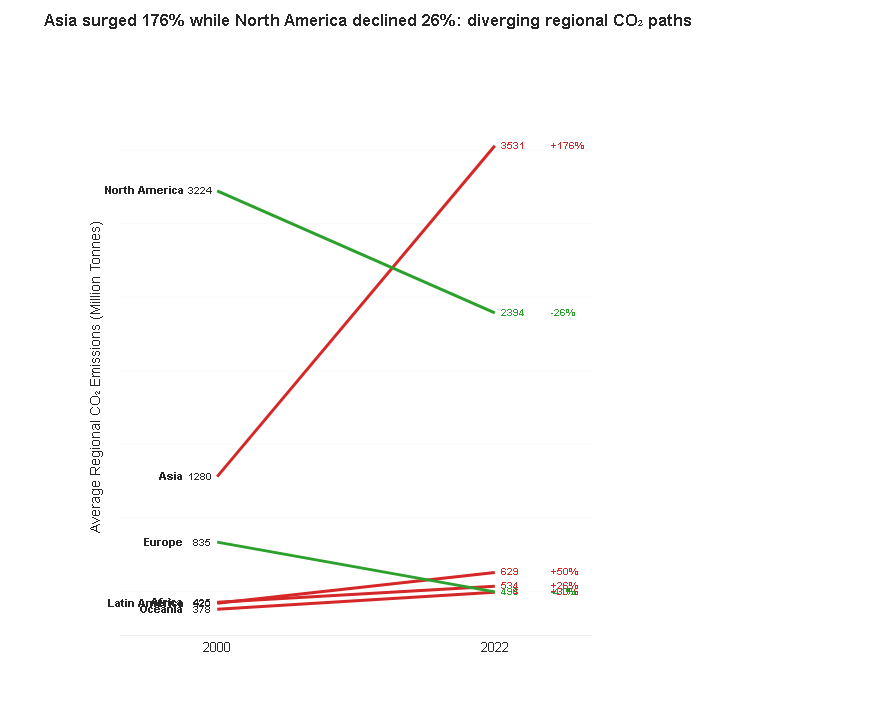

In [14]:
# Task 2 — Slopegraph: regional averages
# Aggregate: average CO2 emissions by region and year
regional_agg = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()

# Filter to start and end years
years_to_plot = [2000, 2022]
slopegraph_data = regional_agg[regional_agg['Year'].isin(years_to_plot)]

# Pivot for easier comparison
slope_pivot = slopegraph_data.pivot(index='Region', columns='Year', values='CO2_Mt')
slope_pivot['Change'] = slope_pivot[2022] - slope_pivot[2000]
slope_pivot['Direction'] = slope_pivot['Change'].apply(lambda x: 'Increase' if x > 0 else 'Decrease')
slope_pivot = slope_pivot.sort_values('Change', ascending=False).reset_index()

print("\nRegional CO2 Emissions Change (2000 → 2022):")
print(slope_pivot[['Region', 2000, 2022, 'Change', 'Direction']].to_string(index=False))

#slopegraph with LARGER size for better spacing
fig2 = go.Figure()

# Colour scheme: red for increase, green for decrease
colour_increase = '#d62728'  # Professional red
colour_decrease = '#2ca02c'  # Professional green
colour_text = '#262626'

#slope lines for each region
for idx, row in slope_pivot.iterrows():
    region = row['Region']
    val_2000 = row[2000]
    val_2022 = row[2022]
    direction = row['Direction']
    
    #colour based on direction
    line_colour = colour_increase if direction == 'Increase' else colour_decrease
    
    #the slope line
    fig2.add_trace(go.Scatter(
        x=[0, 1],
        y=[val_2000, val_2022],
        mode='lines',
        name=region,
        line=dict(color=line_colour, width=3),  # Increased line width
        hovertemplate=f'<b>{region}</b><br>%{{y:.1f}} Mt<extra></extra>',
        showlegend=False
    ))
    
   
    fig2.add_annotation(
        x=-0.12,
        y=val_2000,
        text=f"<b>{region}</b>",
        showarrow=False,
        xanchor='right',
        yanchor='middle',
        font=dict(size=11, color=colour_text, family='Arial', weight='bold')
    )
    
   
    fig2.add_annotation(
        x=-0.02,
        y=val_2000,
        text=f"{val_2000:.0f}",
        showarrow=False,
        xanchor='right',
        yanchor='middle',
        font=dict(size=10, color=colour_text, family='Arial')
    )
    
  
    fig2.add_annotation(
        x=1.02,
        y=val_2022,
        text=f"{val_2022:.0f}",
        showarrow=False,
        xanchor='left',
        yanchor='middle',
        font=dict(size=10, color=line_colour, family='Arial', weight='bold')
    )
    
    
    pct_change = ((val_2022 - val_2000) / val_2000 * 100) if val_2000 != 0 else 0
    fig2.add_annotation(
        x=1.20,
        y=val_2022,
        text=f"{pct_change:+.0f}%",
        showarrow=False,
        xanchor='left',
        yanchor='middle',
        font=dict(size=10, color=line_colour, family='Arial', weight='bold')
    )


fig2.update_layout(
    title=dict(
        text="<b>Asia surged 176% while North America declined 26%: diverging regional CO₂ paths</b>",
        font=dict(size=17, color=colour_text, family='Arial'),
        x=0.05,
        xanchor='left',
        y=0.98,
        yanchor='top'
    ),
    xaxis=dict(
        tickvals=[0, 1],
        ticktext=['2000', '2022'],
        showgrid=False,
        zeroline=False,
        linecolor='#EEEEEE',
        linewidth=1,
        tickfont=dict(size=13, family='Arial', color=colour_text),
        range=[-0.35, 1.35]  # More space on sides
    ),
    yaxis=dict(
        title='Average Regional CO₂ Emissions (Million Tonnes)',
        showgrid=True,
        gridwidth=0.5,
        gridcolor='#F5F5F5',
        zeroline=False,
        tickfont=dict(size=11, family='Arial'),
        showticklabels=False  # No y-axis labels — endpoint values are sufficient
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1200,      # MUCH WIDER for label spacing
    height=700,      # TALLER for region spacing
    margin=dict(l=120, r=280, t=120, b=80),  # Much larger margins
    font=dict(family='Arial', color=colour_text),
    hovermode='closest'
)

# Clean spines
fig2.update_xaxes(showline=True, linewidth=1, linecolor='#EEEEEE')
fig2.update_yaxes(showline=False, linewidth=0)

fig2.show()

        